<a href="https://colab.research.google.com/github/Karthikreddy1010/Electric-poles-and-wires-detection/blob/main/pole_obb_conversion_pipeline_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Utility Pole Dataset: YOLO Axis-Aligned BBox → YOLO-OBB Conversion Pipeline

**Goal:** Convert ~3,000 YOLO axis-aligned bounding box annotations of utility poles into
Ultralytics YOLO-OBB format, estimating **real orientation** (not zero-rotation), with
automated quality control, visualization, and training-ready outputs.

**Pipeline used per box:**
```
BBox → crop → SAM2 (if available) → binary mask → largest connected component
     → cv2.minAreaRect() → 4 corner points → normalized OBB label
```
If SAM2 / segment-anything is not installed or fails to load, an automatic classical
computer-vision fallback is used instead:
```
BBox crop → Canny edges → morphological close → Hough line transform (dominant angle)
     → contour detection → cv2.minAreaRect() → 4 corner points
```

**What this notebook does, in order:**
1. Dataset analysis & quality report
2. BBox → OBB conversion (SAM2 or classical CV fallback), preserving class IDs
3. YOLO-OBB label generation
4. Automated QC flagging → `qc/flagged/`
5. Visualization of ≥200 random before/after samples
6. Dataset statistics (angles, aspect ratios, etc.)
7. Output folder structure (`dataset/images`, `labels_obb`, `qc`, `reports`)
8. `dataset.yaml` for YOLOv8-OBB training
9. Reproducible script + this README

> **Note:** Original images are never modified — only read. All new artifacts are written
> to a fresh `dataset/` tree.


## 0. Setup — install dependencies (Colab)

In [ ]:

!pip -q install ultralytics opencv-python-headless numpy pandas matplotlib tqdm shapely nbformat
# Try to install SAM2 (Segment Anything 2). This is optional — the pipeline auto-falls back
# to classical CV if this is unavailable or fails to load a checkpoint.
!pip -q install git+https://github.com/facebookresearch/sam2.git || echo "SAM2 install failed - will use classical CV fallback"

# Download the SAM2.1 checkpoint (large variant). The pip-installed sam2 package ships
# code + configs only, NOT weights -- without this step USE_SAM2=True below fails inside
# build_sam2() and the pipeline silently falls back to classical CV for every box, which
# is almost certainly why 'USE_SAM2=True' still produced the classical-CV mAP.
!mkdir -p /content/checkpoints
!wget -q -nc https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt -P /content/checkpoints
!ls -la /content/checkpoints
print("Dependency installation complete.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 4.9 MB/s eta 0:00:00
total 877048
drwxr-xr-x 2 root root      4096 Jul 21 17:10 .
drwxr-xr-x 1 root root      4096 Jul 21 17:10 ..
-rw-r--r-- 1 root root 898083611 Sep 29  2024 sam2.1_hiera_large.pt
Dependency installation complete.


In [ ]:
!pip install ultralytics

## 1. Imports & Logging

In [ ]:

import os, sys, json, glob, shutil, random, logging, math, time, traceback
from pathlib import Path
from collections import defaultdict

import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import yaml

random.seed(42)
np.random.seed(42)

# ---- Logging setup: logs every processing step to console + file ----
LOG_PATH = "conversion_pipeline.log"
logger = logging.getLogger("pole_obb_pipeline")
logger.setLevel(logging.INFO)
logger.handlers.clear()
fmt = logging.Formatter("%(asctime)s | %(levelname)-7s | %(message)s", "%H:%M:%S")

fh = logging.FileHandler(LOG_PATH, mode="w")
fh.setFormatter(fmt)
logger.addHandler(fh)

sh = logging.StreamHandler(sys.stdout)
sh.setFormatter(fmt)
logger.addHandler(sh)

logger.info("Logger initialized. Full log will be saved to %s", LOG_PATH)


17:10:41 | INFO    | Logger initialized. Full log will be saved to conversion_pipeline.log


INFO:pole_obb_pipeline:Logger initialized. Full log will be saved to conversion_pipeline.log


## 2. Configuration

Edit `SOURCE_ROOT` to point at your existing dataset (mount Google Drive first if needed).
Expected input layout (standard Ultralytics YOLO):

```
SOURCE_ROOT/
    images/{train,val,test}/*.jpg
    labels/{train,val,test}/*.txt      # class cx cy w h  (normalized, axis-aligned)
```


In [ ]:
!unzip /content/Pole_dataset_Arayan_Sunayana.zip

In [ ]:

from google.colab import drive
try:
    drive.mount('/content/drive')
except Exception as e:
    logger.warning("Not running in Colab or drive mount failed: %s", e)

import os
import math
import logging
from collections import defaultdict

# NOTE: don't do `logger = logging.getLogger(__name__)` here -- that creates a DIFFERENT
# logger object than the "pole_obb_pipeline" one configured in the Imports & Logging cell
# (with the file handler writing conversion_pipeline.log), silently dropping all later
# logger.info/.warning calls in this notebook from that log file. Only create a fallback
# logger if this cell is somehow run before the Imports & Logging cell.
try:
    logger
except NameError:
    logging.basicConfig(level=logging.INFO)
    logger = logging.getLogger("pole_obb_pipeline")
    logger.setLevel(logging.INFO)

# ----------------------- USER CONFIG -----------------------
# SOURCE_ROOT can use EITHER of these layouts -- auto-detected per split, no config needed:
#   Layout A: SOURCE_ROOT/images/<split>/...   SOURCE_ROOT/labels/<split>/...
#   Layout B: SOURCE_ROOT/<split>/images/...   SOURCE_ROOT/<split>/labels/...   (e.g. Final_Dataset/train/images)
SOURCE_ROOT   = "/content/Pole_dataset_Arayan_Sunayana"                 # <-- EDIT: your existing YOLO dataset root
OUTPUT_ROOT   = "/content/Final_Dataset/output_obb"       # <-- EDIT: where the new OBB dataset is written
SPLITS        = ["train", "val", "test"]
CLASS_NAMES   = ["Pole"]   # <-- EDIT: your actual class list, in ID order (match data.yaml)

# QC thresholds (tune to your data)
MIN_BOX_PIXELS        = 6          # width or height below this (px) => "very small object"
MAX_ASPECT_RATIO      = 25.0       # long/short side above this => flagged
MIN_ORIENTATION_CONF  = 0.35       # heuristic confidence floor (0-1) => flagged if below
ANGLE_SANITY_DEG      = (0, 180)   # valid OBB angle range after normalization

N_VIS_SAMPLES = 220                # >= 200 required
RANDOM_SEED   = 42

# SAM2 checkpoint config -- must match the checkpoint downloaded in the install cell.
USE_SAM2 = False
# IMPORTANT: the pip-installed sam2 package registers its Hydra configs under
# "configs/sam2.1/...", not the bare "sam2_hiera_l.yaml" name from the original repo
# checkout. The bare name raises a MissingConfigException that the loader cell below
# used to swallow silently, which is the #1 known cause of USE_SAM2=True quietly still
# using classical CV (see facebookresearch/sam2 issue #26).
SAM2_CFG = "configs/sam2.1/sam2.1_hiera_l.yaml"
SAM2_CKPT = "/content/checkpoints/sam2.1_hiera_large.pt"   # downloaded in the install cell above

# ---- Orientation-pipeline quality knobs (added to address noisy classical-CV labels) ----
# Crop padding: expand each bbox crop before orientation estimation so the pole isn't
# truncated right at the box edge -- truncation was a direct source of bad angle estimates.
CROP_PAD_FRAC_W = 0.12   # fraction of box width added to each side
CROP_PAD_FRAC_H = 0.06   # fraction of box height added to each side

# Foreground mask method for the classical-CV fallback: "edges" (Canny + morphology, fast,
# default) or "grabcut" (slower, better foreground/background separation on cluttered
# images, falls back to "edges" automatically if GrabCut finds nothing).
FOREGROUND_METHOD = "edges"

# Drop (don't write) any annotation that fails qc_check_annotation instead of silently
# keeping a noisy/degenerate OBB in the training & eval label files -- previously flagged
# boxes were still written to labels_obb/, polluting both training and mAP evaluation.
# Flagged images are still copied to qc/flagged/ for manual review either way.
DROP_FLAGGED_ANNOTATIONS = True

for p in [OUTPUT_ROOT]:
    os.makedirs(p, exist_ok=True)

# If a data.yaml already exists at SOURCE_ROOT, prefer its class names over the manual list above
import yaml as _yaml
_existing_yaml = os.path.join(SOURCE_ROOT, "data.yaml")
if os.path.isfile(_existing_yaml):
    try:
        with open(_existing_yaml) as _f:
            _y = _yaml.safe_load(_f)
        if isinstance(_y.get("names"), dict):
            CLASS_NAMES = [_y["names"][k] for k in sorted(_y["names"].keys())]
        elif isinstance(_y.get("names"), list):
            CLASS_NAMES = _y["names"]
        logger.info("Loaded class names from existing %s -> %s", _existing_yaml, CLASS_NAMES)
    except Exception as e:
        logger.warning("Found %s but could not parse it (%s); keeping manual CLASS_NAMES=%s", _existing_yaml, e, CLASS_NAMES)

logger.info("Config loaded. SOURCE_ROOT=%s OUTPUT_ROOT=%s USE_SAM2=%s CLASS_NAMES=%s", SOURCE_ROOT, OUTPUT_ROOT, USE_SAM2, CLASS_NAMES)


Mounted at /content/drive
17:11:37 | INFO    | Loaded class names from existing /content/Pole_dataset_Arayan_Sunayana/data.yaml -> ['pole']


INFO:pole_obb_pipeline:Loaded class names from existing /content/Pole_dataset_Arayan_Sunayana/data.yaml -> ['pole']


17:11:37 | INFO    | Config loaded. SOURCE_ROOT=/content/Pole_dataset_Arayan_Sunayana OUTPUT_ROOT=/content/Final_Dataset/output_obb USE_SAM2=False CLASS_NAMES=['pole']


INFO:pole_obb_pipeline:Config loaded. SOURCE_ROOT=/content/Pole_dataset_Arayan_Sunayana OUTPUT_ROOT=/content/Final_Dataset/output_obb USE_SAM2=False CLASS_NAMES=['pole']


## 3. Task 1 — Dataset Analysis & Quality Report

Checks performed:
- Format detection (axis-aligned YOLO `class cx cy w h`)
- Image ↔ label pairing (every label has an image and vice versa)
- Corrupted / malformed label lines (wrong token count, non-numeric, NaN)
- Out-of-range normalized coordinates (< 0 or > 1)
- Boxes exceeding image boundaries
- Duplicate annotations (identical class+coords within a tolerance, in the same file)


In [ ]:
import math
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

# Two common Ultralytics-style layouts are supported and auto-detected per split:
#   Layout A: SOURCE_ROOT/images/<split>/...   SOURCE_ROOT/labels/<split>/...
#   Layout B: SOURCE_ROOT/<split>/images/...   SOURCE_ROOT/<split>/labels/...
def _first_existing_nonempty(candidates):
    for c in candidates:
        if os.path.isdir(c) and len(os.listdir(c)) > 0:
            return c
    for c in candidates:
        if os.path.isdir(c):
            return c
    return candidates[0]

def find_images_dir(split):
    candidates = [
        os.path.join(SOURCE_ROOT, "images", split),   # layout A
        os.path.join(SOURCE_ROOT, split, "images"),   # layout B
    ]
    return _first_existing_nonempty(candidates)

def find_labels_dir(split):
    candidates = [
        os.path.join(SOURCE_ROOT, "labels", split),   # layout A
        os.path.join(SOURCE_ROOT, split, "labels"),   # layout B
    ]
    return _first_existing_nonempty(candidates)

def log_detected_layout():
    for split in SPLITS:
        img_dir, lbl_dir = find_images_dir(split), find_labels_dir(split)
        logger.info("[%s] resolved images dir -> %s (exists=%s)", split, img_dir, os.path.isdir(img_dir))
        logger.info("[%s] resolved labels dir -> %s (exists=%s)", split, lbl_dir, os.path.isdir(lbl_dir))

log_detected_layout()

def list_stems(folder, exts=None):
    if not os.path.isdir(folder):
        return {}
    out = {}
    for f in os.listdir(folder):
        stem, ext = os.path.splitext(f)
        if exts is None or ext.lower() in exts:
            out[stem] = f
    return out

def parse_yolo_line(line, line_no, fname):
    # Returns dict or raises ValueError with a descriptive message.
    parts = line.strip().split()
    if len(parts) != 5:
        raise ValueError(f"{fname}:{line_no} expected 5 tokens (class cx cy w h), got {len(parts)}")
    try:
        cls = int(float(parts[0]))
        cx, cy, w, h = (float(x) for x in parts[1:])
    except Exception as e:
        raise ValueError(f"{fname}:{line_no} non-numeric token: {e}")
    for v, name in [(cx,"cx"),(cy,"cy"),(w,"w"),(h,"h")]:
        if math.isnan(v) or math.isinf(v):
            raise ValueError(f"{fname}:{line_no} {name} is NaN/inf")
    return {"cls": cls, "cx": cx, "cy": cy, "w": w, "h": h}

def analyze_split(split):
    img_dir, lbl_dir = find_images_dir(split), find_labels_dir(split)
    imgs = list_stems(img_dir, IMG_EXTS)
    lbls = list_stems(lbl_dir, {".txt"})

    report = {
        "split": split,
        "n_images": len(imgs),
        "n_labels": len(lbls),
        "images_without_labels": sorted(set(imgs) - set(lbls)),
        "labels_without_images": sorted(set(lbls) - set(imgs)),
        "corrupted_lines": [],       # (file, line_no, reason)
        "out_of_bounds": [],         # (file, line_no, box)
        "duplicates": [],            # (file, [line_nos])
        "valid_boxes": 0,
        "total_lines": 0,
    }

    for stem, lblfile in lbls.items():
        fpath = os.path.join(lbl_dir, lblfile)
        try:
            with open(fpath, "r") as f:
                lines = [l for l in f.readlines() if l.strip()]
        except Exception as e:
            report["corrupted_lines"].append((lblfile, -1, f"cannot read file: {e}"))
            continue

        seen = []
        for i, line in enumerate(lines, 1):
            report["total_lines"] += 1
            try:
                box = parse_yolo_line(line, i, lblfile)
            except ValueError as e:
                report["corrupted_lines"].append((lblfile, i, str(e)))
                continue

            cx, cy, w, h = box["cx"], box["cy"], box["w"], box["h"]
            x1, y1, x2, y2 = cx - w/2, cy - h/2, cx + w/2, cy + h/2
            if min(x1, y1) < -1e-4 or max(x2, y2) > 1 + 1e-4 or w <= 0 or h <= 0:
                report["out_of_bounds"].append((lblfile, i, [round(x1,4), round(y1,4), round(x2,4), round(y2,4)]))
            else:
                report["valid_boxes"] += 1

            key = (box["cls"], round(cx,4), round(cy,4), round(w,4), round(h,4))
            seen.append((key, i))

        seen_keys = defaultdict(list)
        for key, i in seen:
            seen_keys[key].append(i)
        dups = {k: v for k, v in seen_keys.items() if len(v) > 1}
        if dups:
            report["duplicates"].append((lblfile, dups))

    logger.info("[%s] images=%d labels=%d missing_labels=%d missing_images=%d corrupted=%d oob=%d dup_files=%d",
                split, report["n_images"], report["n_labels"], len(report["images_without_labels"]),
                len(report["labels_without_images"]), len(report["corrupted_lines"]),
                len(report["out_of_bounds"]), len(report["duplicates"]))
    return report

quality_reports = {s: analyze_split(s) for s in SPLITS}
logger.info("Task 1 complete: dataset analysis finished for all splits.")


17:11:41 | INFO    | [train] resolved images dir -> /content/Pole_dataset_Arayan_Sunayana/train/images (exists=True)


INFO:pole_obb_pipeline:[train] resolved images dir -> /content/Pole_dataset_Arayan_Sunayana/train/images (exists=True)


17:11:41 | INFO    | [train] resolved labels dir -> /content/Pole_dataset_Arayan_Sunayana/train/labels (exists=True)


INFO:pole_obb_pipeline:[train] resolved labels dir -> /content/Pole_dataset_Arayan_Sunayana/train/labels (exists=True)


17:11:41 | INFO    | [val] resolved images dir -> /content/Pole_dataset_Arayan_Sunayana/val/images (exists=True)


...

INFO:pole_obb_pipeline:[val] images=486 labels=486 missing_labels=0 missing_images=0 corrupted=0 oob=0 dup_files=0


17:11:41 | INFO    | [test] images=942 labels=942 missing_labels=0 missing_images=0 corrupted=0 oob=0 dup_files=0


INFO:pole_obb_pipeline:[test] images=942 labels=942 missing_labels=0 missing_images=0 corrupted=0 oob=0 dup_files=0


17:11:41 | INFO    | Task 1 complete: dataset analysis finished for all splits.


INFO:pole_obb_pipeline:Task 1 complete: dataset analysis finished for all splits.


In [ ]:

import json
# ---- Write human-readable + machine-readable quality report ----
os.makedirs(os.path.join(OUTPUT_ROOT, "reports"), exist_ok=True)
qr_path_json = os.path.join(OUTPUT_ROOT, "reports", "quality_report.json")
qr_path_md   = os.path.join(OUTPUT_ROOT, "reports", "quality_report.md")

with open(qr_path_json, "w") as f:
    json.dump(quality_reports, f, indent=2, default=str)

with open(qr_path_md, "w") as f:
    f.write("# Dataset Quality Report\n\n")
    f.write("Detected format: **YOLO axis-aligned bounding box** (`class cx cy w h`, normalized)\n\n")
    for s, r in quality_reports.items():
        f.write(f"## Split: {s}\n\n")
        f.write(f"- Images: {r['n_images']}\n")
        f.write(f"- Label files: {r['n_labels']}\n")
        f.write(f"- Total annotation lines: {r['total_lines']}\n")
        f.write(f"- Valid boxes: {r['valid_boxes']}\n")
        f.write(f"- Images without labels: {len(r['images_without_labels'])}\n")
        f.write(f"- Labels without images: {len(r['labels_without_images'])}\n")
        f.write(f"- Corrupted/malformed lines: {len(r['corrupted_lines'])}\n")
        f.write(f"- Out-of-bounds boxes: {len(r['out_of_bounds'])}\n")
        f.write(f"- Files with duplicate annotations: {len(r['duplicates'])}\n\n")

logger.info("Quality report written to %s and %s", qr_path_json, qr_path_md)
print(open(qr_path_md).read())


17:11:46 | INFO    | Quality report written to /content/Final_Dataset/output_obb/reports/quality_report.json and /content/Final_Dataset/output_obb/reports/quality_report.md


INFO:pole_obb_pipeline:Quality report written to /content/Final_Dataset/output_obb/reports/quality_report.json and /content/Final_Dataset/output_obb/reports/quality_report.md


# Dataset Quality Report

Detected format: **YOLO axis-aligned bounding box** (`class cx cy w h`, normalized)

## Split: train

- Images: 6049
- Label files: 6049
- Total annotation lines: 7719
- Valid boxes: 7719
- Images without labels: 0
- Labels without images: 0
- Corrupted/malformed lines: 0
- Out-of-bounds boxes: 0
- Files with duplicate annotations: 0

## Split: val

- Images: 486
- Label files: 486
- Total annotation lines: 527
- Valid boxes: 527
- Images without labels: 0
- Labels without images: 0
- Corrupted/malformed lines: 0
- Out-of-bounds boxes: 0
- Files with duplicate annotations: 0

## Split: test

- Images: 942
- Label files: 942
- Total annotation lines: 1026
- Valid boxes: 1026
- Images without labels: 0
- Labels without images: 0
- Corrupted/malformed lines: 0
- Out-of-bounds boxes: 0
- Files with duplicate annotations: 0




## 4. Task 2/3 — Orientation Estimation & BBox → OBB Conversion

Two interchangeable orientation estimators are implemented:

1. **`estimate_orientation_sam2`** — crops the box, runs SAM2 to get a binary mask,
   keeps the largest connected component, fits `cv2.minAreaRect()` to the mask.
2. **`estimate_orientation_classical`** — Canny edges → morphological close →
   Hough line transform to find the dominant edge angle → contour extraction →
   `cv2.minAreaRect()` on the contour, using the Hough angle to disambiguate/refine
   the rectangle's rotation for elongated pole shapes.

`estimate_orientation()` dispatches to SAM2 if `USE_SAM2` is True and a predictor loaded
successfully; otherwise it always uses the classical fallback — so the pipeline runs
end-to-end even with zero extra setup.

Each estimate returns `(4x2 corner points in crop space, angle_deg, confidence 0-1)`.


In [ ]:

import cv2
# ---------------- Optional SAM2 predictor ----------------
sam2_predictor = None
if USE_SAM2:
    if not os.path.isfile(SAM2_CKPT):
        logger.error(
            "USE_SAM2=True but no checkpoint at %s -- did the download cell (pip install "
            "section) run successfully? Falling back to classical CV pipeline for ALL boxes.",
            SAM2_CKPT)
    else:
        try:
            from sam2.build_sam import build_sam2
            from sam2.sam2_image_predictor import SAM2ImagePredictor
            # NOTE: cv2.cuda.getCudaEnabledDeviceCount() throws on opencv-python-headless
            # (it isn't built with CUDA support), which used to get swallowed by the broad
            # except below and silently force classical CV even with a checkpoint present.
            # torch already reports CUDA availability correctly, so use that instead.
            device = "cuda" if torch.cuda.is_available() else "cpu"
            sam2_model = build_sam2(SAM2_CFG, SAM2_CKPT, device=device)
            sam2_predictor = SAM2ImagePredictor(sam2_model)
            logger.info("SAM2 predictor loaded successfully on device=%s. Using SAM2 for mask-based orientation estimation.", device)
        except Exception as e:
            # exc_info=True so a config/checkpoint mismatch is loud instead of quietly
            # degrading the whole run to classical CV with no visible explanation.
            logger.error("Could not load SAM2 (%s: %s). Falling back to classical CV pipeline for ALL boxes.",
                         type(e).__name__, e, exc_info=True)
            sam2_predictor = None
else:
    logger.info("USE_SAM2=False. Using classical CV fallback pipeline for ALL boxes.")

print(f"SAM2 active for this run: {sam2_predictor is not None}")


def largest_component_mask(binary_mask):
    # Keep only the largest connected component of a binary (0/255) mask.
    n, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)
    if n <= 1:
        return binary_mask
    largest = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    out = np.zeros_like(binary_mask)
    out[labels == largest] = 255
    return out


def pca_oriented_box(mask_pts):
    '''Fit an oriented rectangle via PCA on foreground pixel coordinates, instead of
    cv2.minAreaRect's angle (which flips 90 degrees unpredictably on near-square or
    cluttered masks) or a Hough-line median (which weights wires/fences/building edges
    equally with the pole itself). The principal eigenvector of the point cloud is a much
    more stable estimate of a thin elongated object's long axis.
    Returns (box_pts[4,2] float32, angle_deg, eccentricity). eccentricity = ratio of the
    two eigenvalues; large values mean "long and thin", i.e. pole-shaped, and are used as
    a confidence signal below.'''
    mean = mask_pts.mean(axis=0)
    centered = mask_pts - mean
    cov = np.cov(centered.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    principal = eigvecs[:, 0]
    angle = math.degrees(math.atan2(principal[1], principal[0])) % 180

    theta = math.radians(angle)
    rot = np.array([[math.cos(theta), math.sin(theta)],
                     [-math.sin(theta), math.cos(theta)]])
    aligned = centered @ rot.T
    (minx, miny), (maxx, maxy) = aligned.min(axis=0), aligned.max(axis=0)
    box_aligned = np.array([[minx, miny], [maxx, miny], [maxx, maxy], [minx, maxy]], dtype=np.float32)
    box = (box_aligned @ rot) + mean
    eccentricity = float(eigvals[0] / max(eigvals[1], 1e-6))
    return box.astype(np.float32), angle, eccentricity


def estimate_orientation_sam2(crop_bgr):
    '''Use SAM2 to segment the pole inside the crop, then fit a PCA-oriented rectangle to
    the mask (instead of cv2.minAreaRect, for the same stability reasons as the classical
    path below). Returns (box_pts[4,2] float32, angle_deg, confidence) or None on failure.'''
    try:
        h, w = crop_bgr.shape[:2]
        rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        sam2_predictor.set_image(rgb)
        # Prompt with a box covering the whole crop plus a center point (typical SAM2 usage)
        input_box = np.array([0, 0, w - 1, h - 1])
        input_point = np.array([[w // 2, h // 2]])
        input_label = np.array([1])
        masks, scores, _ = sam2_predictor.predict(
            point_coords=input_point, point_labels=input_label,
            box=input_box, multimask_output=True
        )
        best = int(np.argmax(scores))
        mask = (masks[best] > 0.5).astype(np.uint8) * 255
        mask = largest_component_mask(mask)
        ys, xs = np.where(mask > 0)
        if len(xs) < 10:
            return None
        pts = np.column_stack([xs, ys]).astype(np.float32)
        box_pts, angle, eccentricity = pca_oriented_box(pts)
        # Blend SAM2's own mask-quality score with how elongated/pole-like the mask is.
        confidence = float(0.7 * scores[best] + 0.3 * min(1.0, eccentricity / 8.0))
        return box_pts, angle, confidence
    except Exception as e:
        logger.debug("SAM2 estimation failed on crop: %s", e)
        return None


# ---------------- Classical CV fallback: foreground mask + PCA orientation ----------------

def foreground_mask_edges(gray):
    '''Canny + morphological close (kernel sized to the crop instead of a fixed (3,9),
    which under-closes large crops and over-closes small ones), THEN filled via the
    largest external contour. Without this fill step, PCA was running on a hollow outline
    of edge pixels rather than the solid object -- for wide poles that biases the
    eigenvector and understates eccentricity (the confidence signal), even though it
    happened to look fine on narrow poles where closing accidentally filled the interior.'''
    h, w = gray.shape[:2]
    edges = cv2.Canny(gray, 50, 150)
    kh = max(9, int(h / 15))
    kw = max(3, int(w / 5))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kw, kh))
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)
    closed = cv2.dilate(closed, np.ones((3, 3), np.uint8), iterations=1)

    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return closed   # nothing to fill; caller's len(xs) < 10 check will catch this
    largest = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest) < 4:
        return closed
    filled = np.zeros_like(closed)
    cv2.drawContours(filled, [largest], -1, 255, thickness=cv2.FILLED)
    return filled


def foreground_mask_grabcut(crop_bgr):
    '''GrabCut foreground/background separation, initialized with a generous inner rect
    (poles are usually roughly centered in their own crop). Returns None on failure so
    callers can fall back to the edge-based mask.'''
    try:
        h, w = crop_bgr.shape[:2]
        mask = np.zeros((h, w), np.uint8)
        bgd_model = np.zeros((1, 65), np.float64)
        fgd_model = np.zeros((1, 65), np.float64)
        margin_x, margin_y = max(1, int(0.08 * w)), max(1, int(0.03 * h))
        rect = (margin_x, margin_y, max(1, w - 2 * margin_x), max(1, h - 2 * margin_y))
        cv2.grabCut(crop_bgr, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)
        fg = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 255, 0).astype(np.uint8)
        return fg
    except Exception as e:
        logger.debug("GrabCut failed on crop: %s", e)
        return None


def wire_filtered_hough_support(closed_mask, h):
    '''Hough line count restricted to near-vertical lines (60-120 deg), i.e. plausible pole
    segments. Used only as a secondary confidence signal now -- NOT to set the angle -- since
    unfiltered Hough previously weighted wires/fences/building edges the same as the pole.'''
    lines = cv2.HoughLinesP(closed_mask, 1, np.pi / 180, threshold=20,
                             minLineLength=max(10, int(0.3 * h)), maxLineGap=8)
    if lines is None:
        return 0
    support = 0
    for x1, y1, x2, y2 in lines[:, 0]:
        dx, dy = x2 - x1, y2 - y1
        if dx == 0 and dy == 0:
            continue
        ang = math.degrees(math.atan2(dy, dx)) % 180
        if 60 <= ang <= 120:
            support += 1
    return support


def estimate_orientation_classical(crop_bgr):
    '''Classical CV fallback, rebuilt around PCA instead of Hough-median-angle +
    cv2.minAreaRect:
        crop -> CLAHE contrast boost -> foreground mask (edges or GrabCut, config-selected)
             -> largest connected component -> PCA orientation -> OBB corners
    Hough is retained only as a wire-filtered secondary confidence signal (see
    wire_filtered_hough_support), not as the orientation source.
    Returns (box_pts[4,2] float32, angle_deg, confidence).'''
    h, w = crop_bgr.shape[:2]
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    if FOREGROUND_METHOD == "grabcut":
        mask = foreground_mask_grabcut(crop_bgr)
        if mask is None or mask.sum() == 0:
            mask = foreground_mask_edges(gray)
    else:
        mask = foreground_mask_edges(gray)

    mask = largest_component_mask(mask)
    ys, xs = np.where(mask > 0)
    hough_support = wire_filtered_hough_support(mask, h)
    hough_conf = min(1.0, hough_support / 15.0)

    if len(xs) < 10:
        # No usable foreground. Previously this silently returned the bbox itself as a
        # "0-degree" OBB, indistinguishable from a real vertical-pole estimate (this is
        # why the old label set's median angle landed exactly on 90 deg). Now it's
        # returned at confidence 0.0 so QC (and DROP_FLAGGED_ANNOTATIONS) actually removes
        # it instead of it masquerading as a real orientation estimate.
        box_pts = np.array([[0, 0], [w, 0], [w, h], [0, h]], dtype=np.float32)
        return box_pts, 90.0, 0.0

    pts = np.column_stack([xs, ys]).astype(np.float32)
    box_pts, angle, eccentricity = pca_oriented_box(pts)

    fill_ratio = min(1.0, len(xs) / float(w * h + 1e-6))
    eccentricity_score = min(1.0, eccentricity / 8.0)   # poles are strongly elongated
    confidence = float(0.4 * fill_ratio + 0.3 * eccentricity_score + 0.3 * hough_conf)

    return box_pts, angle, confidence


def estimate_orientation(crop_bgr):
    if sam2_predictor is not None:
        result = estimate_orientation_sam2(crop_bgr)
        if result is not None:
            return result, "sam2"
        logger.debug("SAM2 returned no result for a crop; using classical fallback for this box.")
    return estimate_orientation_classical(crop_bgr), "classical_cv"

logger.info("Orientation estimators ready (sam2_available=%s, foreground_method=%s).",
            sam2_predictor is not None, FOREGROUND_METHOD)


17:11:50 | INFO    | USE_SAM2=False. Using classical CV fallback pipeline for ALL boxes.


INFO:pole_obb_pipeline:USE_SAM2=False. Using classical CV fallback pipeline for ALL boxes.


SAM2 active for this run: False
17:11:50 | INFO    | Orientation estimators ready (sam2_available=False, foreground_method=edges).


INFO:pole_obb_pipeline:Orientation estimators ready (sam2_available=False, foreground_method=edges).


## 5. Conversion Core — YOLO bbox → YOLO-OBB per image

In [ ]:

def yolo_line_to_pixel_box(cx, cy, w, h, img_w, img_h):
    x1 = (cx - w / 2) * img_w
    y1 = (cy - h / 2) * img_h
    x2 = (cx + w / 2) * img_w
    y2 = (cy + h / 2) * img_h
    return max(0, x1), max(0, y1), min(img_w, x2), min(img_h, y2)


def order_points_clockwise(pts):
    '''Order 4 points starting top-left, clockwise -- standard for YOLO-OBB.'''
    pts = np.array(pts, dtype=np.float32)
    c = pts.mean(axis=0)
    angles = np.arctan2(pts[:, 1] - c[1], pts[:, 0] - c[0])
    order = np.argsort(angles)
    pts = pts[order]
    # rotate so the point closest to top-left is first
    sums = pts[:, 0] + pts[:, 1]
    start = int(np.argmin(sums))
    pts = np.roll(pts, -start, axis=0)
    return pts


def convert_box_to_obb(img, cls, cx, cy, w, h):
    '''Full per-annotation pipeline: bbox -> padded crop -> orientation estimate -> OBB
    corners in absolute image pixel coordinates. Returns dict with corners, angle,
    confidence, method.
    The crop is expanded by CROP_PAD_FRAC_W/H beyond the raw bbox before orientation
    estimation -- cropping exactly at the bbox edge was truncating poles right where the
    edge/Hough/PCA signal matters most, which skewed angle estimates near crop boundaries.'''
    img_h, img_w = img.shape[:2]
    x1, y1, x2, y2 = yolo_line_to_pixel_box(cx, cy, w, h, img_w, img_h)

    pad_w = CROP_PAD_FRAC_W * (x2 - x1)
    pad_h = CROP_PAD_FRAC_H * (y2 - y1)
    x1p, y1p = max(0, x1 - pad_w), max(0, y1 - pad_h)
    x2p, y2p = min(img_w, x2 + pad_w), min(img_h, y2 + pad_h)

    x1i, y1i, x2i, y2i = int(x1p), int(y1p), max(int(x2p), int(x1p) + 1), max(int(y2p), int(y1p) + 1)
    crop = img[y1i:y2i, x1i:x2i]
    if crop.size == 0:
        return None

    (box_pts, angle, confidence), method = estimate_orientation(crop)
    # translate crop-space points back into full-image pixel coordinates
    abs_pts = box_pts + np.array([x1i, y1i], dtype=np.float32)
    abs_pts = order_points_clockwise(abs_pts)

    return {
        "cls": cls,
        "corners": abs_pts,        # 4x2, absolute pixel coords
        "angle_deg": float(angle),
        "confidence": float(confidence),
        "method": method,
        "orig_box_px": (x1, y1, x2, y2),
    }


def corners_to_yolo_obb_line(cls, corners, img_w, img_h):
    norm = corners.copy().astype(np.float64)
    norm[:, 0] = np.clip(norm[:, 0] / img_w, 0.0, 1.0)
    norm[:, 1] = np.clip(norm[:, 1] / img_h, 0.0, 1.0)
    coords = " ".join(f"{v:.6f}" for v in norm.flatten())
    return f"{cls} {coords}"

logger.info("Conversion core functions ready.")


17:11:57 | INFO    | Conversion core functions ready.


INFO:pole_obb_pipeline:Conversion core functions ready.


## 6. Task 4 — Automated QC Rules

Every converted annotation is checked against:
- Angle sanity (finite, within expected range after normalization)
- Extreme aspect ratio (`long_side / short_side > MAX_ASPECT_RATIO`)
- OBB corners outside image boundary
- Self-intersecting polygon (via Shapely validity check)
- Very small object (either side < `MIN_BOX_PIXELS`)
- Low orientation-estimation confidence (< `MIN_ORIENTATION_CONF`)

Any image with >= 1 flagged annotation is copied (image + its original & OBB label) into
`qc/flagged/` for manual review — the original dataset files are never modified in place.


In [ ]:

from shapely.geometry import Polygon

def qc_check_annotation(conv, img_w, img_h):
    reasons = []
    corners = conv["corners"]

    # aspect ratio
    side_a = np.linalg.norm(corners[0] - corners[1])
    side_b = np.linalg.norm(corners[1] - corners[2])
    long_side, short_side = max(side_a, side_b), max(min(side_a, side_b), 1e-6)
    aspect = long_side / short_side
    if aspect > MAX_ASPECT_RATIO:
        reasons.append(f"extreme_aspect_ratio({aspect:.1f})")

    # very small object
    if short_side < MIN_BOX_PIXELS or long_side < MIN_BOX_PIXELS:
        reasons.append(f"very_small_object(short={short_side:.1f}px)")

    # boundary check
    if (corners[:, 0].min() < -1 or corners[:, 0].max() > img_w + 1 or
        corners[:, 1].min() < -1 or corners[:, 1].max() > img_h + 1):
        reasons.append("obb_exceeds_image_boundary")

    # angle sanity
    ang = conv["angle_deg"]
    if not np.isfinite(ang):
        reasons.append("invalid_angle_nan")

    # self-intersection via shapely validity
    try:
        poly = Polygon(corners)
        if not poly.is_valid or poly.area <= 0:
            reasons.append("self_intersecting_or_degenerate_polygon")
    except Exception:
        reasons.append("polygon_construction_failed")

    # low confidence
    if conv["confidence"] < MIN_ORIENTATION_CONF:
        reasons.append(f"low_orientation_confidence({conv['confidence']:.2f})")

    return reasons

logger.info("QC rule functions ready. Thresholds: MAX_ASPECT_RATIO=%s MIN_BOX_PIXELS=%s MIN_ORIENTATION_CONF=%s",
            MAX_ASPECT_RATIO, MIN_BOX_PIXELS, MIN_ORIENTATION_CONF)


17:12:27 | INFO    | QC rule functions ready. Thresholds: MAX_ASPECT_RATIO=25.0 MIN_BOX_PIXELS=6 MIN_ORIENTATION_CONF=0.35


INFO:pole_obb_pipeline:QC rule functions ready. Thresholds: MAX_ASPECT_RATIO=25.0 MIN_BOX_PIXELS=6 MIN_ORIENTATION_CONF=0.35


## 7. Task 7 — Create Output Folder Structure

In [ ]:

def make_output_tree(root):
    dirs = []
    for split in SPLITS:
        dirs += [f"images/{split}", f"labels_obb/{split}"]
    dirs += ["qc/flagged", "qc/visualizations", "reports"]
    for d in dirs:
        os.makedirs(os.path.join(root, d), exist_ok=True)
    logger.info("Output tree created under %s", root)

make_output_tree(OUTPUT_ROOT)


17:12:31 | INFO    | Output tree created under /content/Final_Dataset/output_obb


INFO:pole_obb_pipeline:Output tree created under /content/Final_Dataset/output_obb


## 8. Run Full Conversion (Tasks 2, 3, 4, 7)

For every split: read each image + its label file, convert every box to OBB, write the
new label to `labels_obb/<split>/`, copy (not move/modify) the image into the new
`images/<split>/` tree, run QC, and copy flagged items into `qc/flagged/`.


In [ ]:
conversion_records = []   # one row per annotation, for stats + QC later
flagged_images = set()

def process_split(split):
    img_dir, lbl_dir = find_images_dir(split), find_labels_dir(split)
    out_img_dir = os.path.join(OUTPUT_ROOT, "images", split)
    out_lbl_dir = os.path.join(OUTPUT_ROOT, "labels_obb", split)

    label_files = sorted(glob.glob(os.path.join(lbl_dir, "*.txt")))
    logger.info("[%s] Converting %d label files... (images dir=%s, labels dir=%s)",
                split, len(label_files), img_dir, lbl_dir)
    if len(label_files) == 0:
        logger.warning("[%s] No .txt label files found in %s -- check SOURCE_ROOT / layout "
                        "detection above (see 'resolved images/labels dir' log lines).", split, lbl_dir)

    for lblpath in tqdm(label_files, desc=f"convert:{split}"):
        stem = Path(lblpath).stem
        img_path = None
        for ext in IMG_EXTS:
            cand = os.path.join(img_dir, stem + ext)
            if os.path.isfile(cand):
                img_path = cand
                break
        if img_path is None:
            logger.warning("[%s] No image found for label %s -- skipping", split, lblpath)
            continue

        img = cv2.imread(img_path)
        if img is None:
            logger.warning("[%s] Failed to read image %s -- skipping", split, img_path)
            continue
        img_h, img_w = img.shape[:2]

        with open(lblpath, "r") as f:
            lines = [l for l in f.readlines() if l.strip()]

        out_lines = []
        any_flag = False
        for i, line in enumerate(lines, 1):
            try:
                box = parse_yolo_line(line, i, lblpath)
            except ValueError as e:
                logger.warning("[%s] %s -- skipping malformed line", split, e)
                continue

            conv = convert_box_to_obb(img, box["cls"], box["cx"], box["cy"], box["w"], box["h"])
            if conv is None:
                logger.warning("[%s] %s:%d produced an empty crop -- skipping", split, stem, i)
                continue

            reasons = qc_check_annotation(conv, img_w, img_h)
            if reasons:
                any_flag = True

            # Previously every converted box -- flagged or not -- was written to
            # labels_obb/ and used for both training and mAP evaluation, so QC-flagged
            # noise (self-intersecting polygons, extreme aspect ratios, near-zero
            # confidence) was silently baked into the label set. With
            # DROP_FLAGGED_ANNOTATIONS=True we keep the record (for stats/manifest) but
            # skip writing the OBB line, so bad geometry never reaches train/val/test.
            dropped = bool(reasons) and DROP_FLAGGED_ANNOTATIONS
            if not dropped:
                out_lines.append(corners_to_yolo_obb_line(conv["cls"], conv["corners"], img_w, img_h))

            conversion_records.append({
                "split": split, "image": os.path.basename(img_path), "stem": stem,
                "ann_idx": i, "cls": conv["cls"],
                "angle_deg": conv["angle_deg"], "confidence": conv["confidence"],
                "method": conv["method"],
                "width_px": float(np.linalg.norm(conv["corners"][0]-conv["corners"][1])),
                "height_px": float(np.linalg.norm(conv["corners"][1]-conv["corners"][2])),
                "flags": ";".join(reasons),
                "img_w": img_w, "img_h": img_h,
                "dropped": dropped,
            })

        # write OBB label file (even if empty, keeps 1:1 correspondence)
        with open(os.path.join(out_lbl_dir, stem + ".txt"), "w") as f:
            f.write("\n".join(out_lines) + ("\n" if out_lines else ""))

        # copy (never move/modify) original image into new tree
        shutil.copy2(img_path, os.path.join(out_img_dir, os.path.basename(img_path)))

        if any_flag:
            flagged_images.add((split, img_path, lblpath, stem))

    logger.info("[%s] Conversion complete.", split)

for s in SPLITS:
    process_split(s)

logger.info("All splits converted. Total annotations processed: %d", len(conversion_records))

if len(conversion_records) == 0:
    raise RuntimeError(
        "conversion_records is empty -- no annotations were converted for any split. "
        "This almost always means find_images_dir()/find_labels_dir() resolved to folders "
        "with no files (check the '[split] resolved images/labels dir -> ... (exists=...)' "
        "log lines from log_detected_layout() above, and confirm SOURCE_ROOT/Final_Dataset.zip "
        "actually extracted to the expected images/<split> and labels/<split> paths). "
        "Fix the path/layout issue and re-run this cell before continuing to visualization "
        "or stats -- otherwise those cells will fail with a confusing pandas KeyError."
    )

17:12:35 | INFO    | [train] Converting 6049 label files... (images dir=/content/Pole_dataset_Arayan_Sunayana/train/images, labels dir=/content/Pole_dataset_Arayan_Sunayana/train/labels)


INFO:pole_obb_pipeline:[train] Converting 6049 label files... (images dir=/content/Pole_dataset_Arayan_Sunayana/train/images, labels dir=/content/Pole_dataset_Arayan_Sunayana/train/labels)
convert:train: 100%|██████████| 6049/6049 [02:12<00:00, 45.60it/s]

17:14:48 | INFO    | [train] Conversion complete.



INFO:pole_obb_pipeline:[train] Conversion complete.


17:14:48 | INFO    | [val] Converting 486 label files... (images dir=/content/Pole_dataset_Arayan_Sunayana/val/images, labels dir=/content/Pole_dataset_Arayan_Sunayana/val/labels)


...

INFO:pole_obb_pipeline:[test] Converting 942 label files... (images dir=/content/Pole_dataset_Arayan_Sunayana/test/images, labels dir=/content/Pole_dataset_Arayan_Sunayana/test/labels)
convert:test: 100%|██████████| 942/942 [00:25<00:00, 37.50it/s]

17:15:26 | INFO    | [test] Conversion complete.



INFO:pole_obb_pipeline:[test] Conversion complete.


17:15:26 | INFO    | All splits converted. Total annotations processed: 9272


INFO:pole_obb_pipeline:All splits converted. Total annotations processed: 9272


In [ ]:

# ---- Copy flagged items into qc/flagged for manual review ----
flag_dir = os.path.join(OUTPUT_ROOT, "qc", "flagged")
flag_manifest = []
for split, img_path, lblpath, stem in flagged_images:
    dest_img = os.path.join(flag_dir, f"{split}__{os.path.basename(img_path)}")
    shutil.copy2(img_path, dest_img)
    obb_lbl_src = os.path.join(OUTPUT_ROOT, "labels_obb", split, stem + ".txt")
    if os.path.isfile(obb_lbl_src):
        shutil.copy2(obb_lbl_src, os.path.join(flag_dir, f"{split}__{stem}_obb.txt"))
    flag_manifest.append({"split": split, "image": os.path.basename(img_path), "stem": stem})

pd.DataFrame(flag_manifest).to_csv(os.path.join(OUTPUT_ROOT, "reports", "flagged_manifest.csv"), index=False)
logger.info("Flagged %d images requiring manual review -> %s", len(flagged_images), flag_dir)


17:15:32 | INFO    | Flagged 657 images requiring manual review -> /content/Final_Dataset/output_obb/qc/flagged


INFO:pole_obb_pipeline:Flagged 657 images requiring manual review -> /content/Final_Dataset/output_obb/qc/flagged


## 9. Task 5 — Visualization: Before/After Comparison (≥200 samples)

Draws the **original axis-aligned bbox** (red) and the **generated OBB** (green) on the
same image for a random sample of at least 200 converted images, saved to
`qc/visualizations/`.


In [ ]:
def draw_comparison(img, orig_boxes_px, obb_list):
    vis = img.copy()
    for (x1, y1, x2, y2) in orig_boxes_px:
        cv2.rectangle(vis, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 255), 2)
    for corners in obb_list:
        pts = corners.astype(int).reshape(-1, 1, 2)
        cv2.polylines(vis, [pts], isClosed=True, color=(0, 255, 0), thickness=2)
    return vis


def visualize_samples(n_samples=N_VIS_SAMPLES):
    df = pd.DataFrame(conversion_records)
    if df.empty:
        logger.warning("visualize_samples: conversion_records is empty -- skipping visualization. "
                        "Re-run the conversion cell (Task 2/3/4/7) above; it should have raised "
                        "a RuntimeError already if this is the case.")
        return
    all_images = df[["split", "image", "stem"]].drop_duplicates()
    n = min(n_samples, len(all_images))
    sample = all_images.sample(n=n, random_state=RANDOM_SEED)

    vis_dir = os.path.join(OUTPUT_ROOT, "qc", "visualizations")
    saved = 0
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="visualize"):
        split, imname, stem = row["split"], row["image"], row["stem"]
        img_path = os.path.join(find_images_dir(split), imname)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img_h, img_w = img.shape[:2]

        # original axis-aligned boxes for this image
        orig_lbl = os.path.join(find_labels_dir(split), stem + ".txt")
        orig_boxes = []
        if os.path.isfile(orig_lbl):
            with open(orig_lbl) as f:
                for line in f:
                    if not line.strip():
                        continue
                    try:
                        b = parse_yolo_line(line, 0, orig_lbl)
                    except ValueError:
                        continue
                    orig_boxes.append(yolo_line_to_pixel_box(b["cx"], b["cy"], b["w"], b["h"], img_w, img_h))

        # converted OBB corners for this image (re-read from the OBB label we just wrote)
        obb_lbl = os.path.join(OUTPUT_ROOT, "labels_obb", split, stem + ".txt")
        obb_list = []
        if os.path.isfile(obb_lbl):
            with open(obb_lbl) as f:
                for line in f:
                    if not line.strip():
                        continue
                    parts = list(map(float, line.strip().split()))
                    pts = np.array(parts[1:]).reshape(4, 2)
                    pts[:, 0] *= img_w
                    pts[:, 1] *= img_h
                    obb_list.append(pts)

        vis = draw_comparison(img, orig_boxes, obb_list)
        cv2.imwrite(os.path.join(vis_dir, f"{split}__{stem}_compare.jpg"), vis)
        saved += 1

    logger.info("Saved %d before/after visualization images to %s", saved, vis_dir)

visualize_samples()

visualize: 100%|██████████| 220/220 [00:02<00:00, 82.79it/s]

17:15:37 | INFO    | Saved 220 before/after visualization images to /content/Final_Dataset/output_obb/qc/visualizations



INFO:pole_obb_pipeline:Saved 220 before/after visualization images to /content/Final_Dataset/output_obb/qc/visualizations


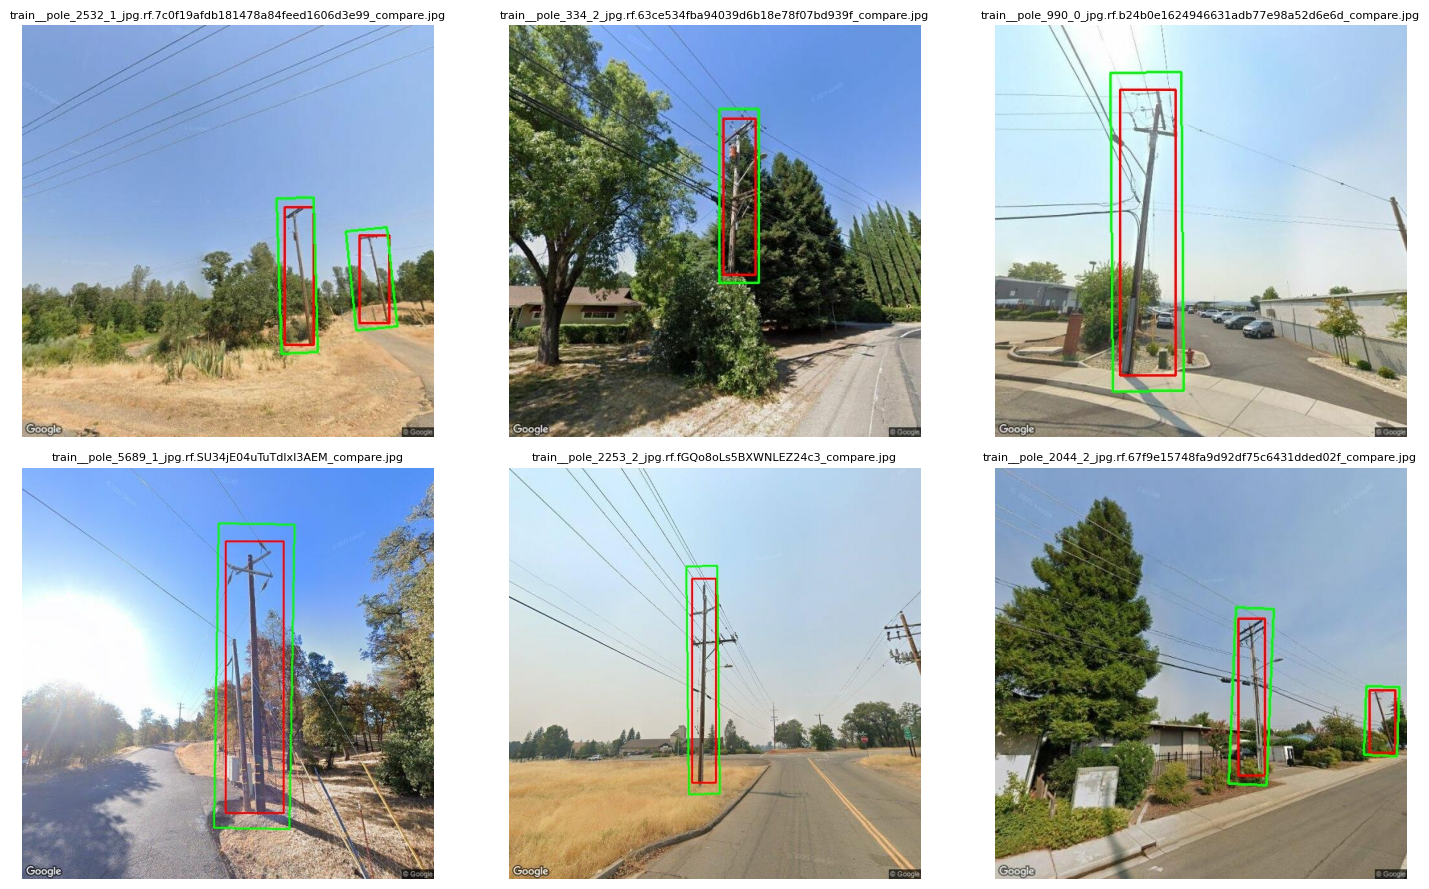

In [ ]:

# quick inline preview of a few comparison images
sample_files = glob.glob(os.path.join(OUTPUT_ROOT, "qc", "visualizations", "*.jpg"))[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, fp in zip(axes.flat, sample_files):
    im = cv2.cvtColor(cv2.imread(fp), cv2.COLOR_BGR2RGB)
    ax.imshow(im); ax.set_title(os.path.basename(fp), fontsize=8); ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, "reports", "sample_preview_grid.png"), dpi=120)
plt.show()


## 10. Task 6 — Dataset Statistics

In [ ]:
df = pd.DataFrame(conversion_records)
if df.empty:
    raise RuntimeError(
        "conversion_records is empty -- no annotations were converted. See the conversion "
        "cell (Task 2/3/4/7) above for the layout-diagnosis error; fix that and re-run from "
        "there before computing stats."
    )
df["short_side"] = df[["width_px","height_px"]].min(axis=1)
df["long_side"]  = df[["width_px","height_px"]].max(axis=1)
df["aspect_ratio"] = df["long_side"] / df["short_side"].replace(0, np.nan)
df["is_flagged"] = df["flags"].str.len() > 0
if "dropped" not in df.columns:
    df["dropped"] = False

stats = {
    "n_images": df[["split","image"]].drop_duplicates().shape[0],
    "n_annotations": len(df),
    "n_annotations_written": int((~df["dropped"]).sum()),
    "n_annotations_dropped": int(df["dropped"].sum()),
    "avg_width_px": df["width_px"].mean(),
    "avg_height_px": df["height_px"].mean(),
    "avg_angle_deg": df["angle_deg"].mean(),
    "median_angle_deg": df["angle_deg"].median(),
    "avg_aspect_ratio": df["aspect_ratio"].mean(),
    "n_flagged_images": df.loc[df["is_flagged"], ["split","image"]].drop_duplicates().shape[0],
    "pct_flagged_annotations": 100 * df["is_flagged"].mean(),
    "sam2_used_frac": (df["method"] == "sam2").mean(),
    "classical_cv_used_frac": (df["method"] == "classical_cv").mean(),
}
stats_df = pd.DataFrame([stats])
stats_path = os.path.join(OUTPUT_ROOT, "reports", "dataset_statistics.csv")
stats_df.to_csv(stats_path, index=False)
df.to_csv(os.path.join(OUTPUT_ROOT, "reports", "per_annotation_details.csv"), index=False)

logger.info("Dataset statistics written to %s", stats_path)
print(stats_df.T)

17:15:50 | INFO    | Dataset statistics written to /content/Final_Dataset/output_obb/reports/dataset_statistics.csv


INFO:pole_obb_pipeline:Dataset statistics written to /content/Final_Dataset/output_obb/reports/dataset_statistics.csv


                                   0
n_images                 7477.000000
n_annotations            9272.000000
n_annotations_written    8596.000000
n_annotations_dropped     676.000000
avg_width_px               66.070581
avg_height_px             324.195815
avg_angle_deg              89.829191
median_angle_deg           90.000000
avg_aspect_ratio            5.427589
n_flagged_images          657.000000
pct_flagged_annotations     7.290768
sam2_used_frac              0.000000
classical_cv_used_frac      1.000000


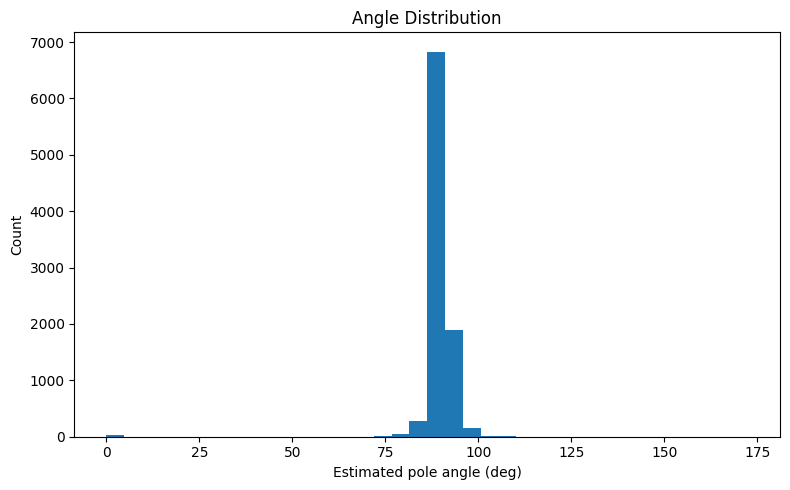

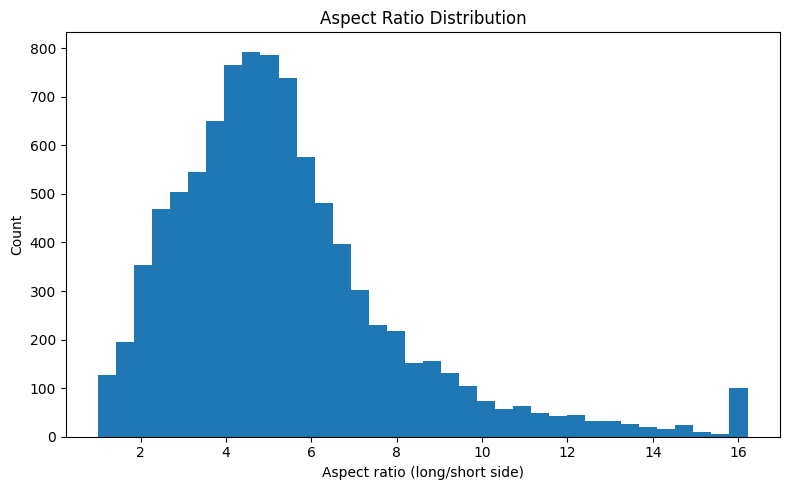

17:15:56 | INFO    | Saved /content/Final_Dataset/output_obb/reports/angle_distribution.png and /content/Final_Dataset/output_obb/reports/aspect_ratio_distribution.png


INFO:pole_obb_pipeline:Saved /content/Final_Dataset/output_obb/reports/angle_distribution.png and /content/Final_Dataset/output_obb/reports/aspect_ratio_distribution.png


In [ ]:

# Angle distribution
plt.figure(figsize=(8,5))
plt.hist(df["angle_deg"].dropna(), bins=36)
plt.xlabel("Estimated pole angle (deg)"); plt.ylabel("Count")
plt.title("Angle Distribution")
angle_plot_path = os.path.join(OUTPUT_ROOT, "reports", "angle_distribution.png")
plt.tight_layout(); plt.savefig(angle_plot_path, dpi=120); plt.show()

# Aspect ratio distribution
plt.figure(figsize=(8,5))
plt.hist(df["aspect_ratio"].clip(upper=df["aspect_ratio"].quantile(0.99)).dropna(), bins=36)
plt.xlabel("Aspect ratio (long/short side)"); plt.ylabel("Count")
plt.title("Aspect Ratio Distribution")
ar_plot_path = os.path.join(OUTPUT_ROOT, "reports", "aspect_ratio_distribution.png")
plt.tight_layout(); plt.savefig(ar_plot_path, dpi=120); plt.show()

logger.info("Saved %s and %s", angle_plot_path, ar_plot_path)


In [ ]:
import shutil
from google.colab import files

output_zip_name = f"{os.path.basename(OUTPUT_ROOT)}.zip"
shutil.make_archive(output_zip_name.replace('.zip', ''), 'zip', OUTPUT_ROOT)

logger.info("Created archive %s for download.", output_zip_name)
files.download(output_zip_name)

17:17:53 | INFO    | Created archive output_obb.zip for download.


INFO:pole_obb_pipeline:Created archive output_obb.zip for download.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>